In [1]:
import cvxpy as cp
import numpy as np

W = 183
H = 200
n = 6
areas = [3600, 10000, 6400, 4900, 8100, 3600]

flows = np.array([
    [0, 0, 20, 40, 60, 0],
    [0, 0, 50, 15, 0, 60],
    [20, 50, 0, 50, 10, 10],
    [40, 15, 50, 0, 10, 0],
    [60, 0, 10, 10, 0, 0],
    [0, 60, 10, 0, 0, 0]
])

x = cp.Variable(n)
y = cp.Variable(n)
l = cp.Variable(n)
w = cp.Variable(n)

constraints = []
M = 10000

for i in range(n):
    constraints.append(l[i] >= 25)
    constraints.append(l[i] <= 200)
    constraints.append(w[i] >= 40)
    constraints.append(w[i] <= 200)
    
    constraints.append(x[i] - 0.5 * l[i] >= 0)
    constraints.append(x[i] + 0.5 * l[i] <= W)
    constraints.append(y[i] - 0.5 * w[i] >= 0)
    constraints.append(y[i] + 0.5 * w[i] <= H)
    
    p = 4 * np.sqrt(areas[i])
    constraints.append(2 * (l[i] + w[i]) >= 0.99 * p)
    constraints.append(2 * (l[i] + w[i]) <= 1.01 * p)

num_pairs = int(n * (n - 1) / 2)
b = cp.Variable((num_pairs, 4), boolean=True)
dx = cp.Variable(num_pairs)
dy = cp.Variable(num_pairs)

obj_total = 0
k = 0

for i in range(n):
    for j in range(i + 1, n):
        constraints.append(x[i] + 0.5*l[i] <= x[j] - 0.5*l[j] + M * (1 - b[k, 0]))
        constraints.append(x[j] + 0.5*l[j] <= x[i] - 0.5*l[i] + M * (1 - b[k, 1]))
        constraints.append(y[i] + 0.5*w[i] <= y[j] - 0.5*w[j] + M * (1 - b[k, 2]))
        constraints.append(y[j] + 0.5*w[j] <= y[i] - 0.5*w[i] + M * (1 - b[k, 3]))
        constraints.append(cp.sum(b[k]) >= 1)
        
        constraints.append(dx[k] >= x[i] - x[j])
        constraints.append(dx[k] >= x[j] - x[i])
        constraints.append(dy[k] >= y[i] - y[j])
        constraints.append(dy[k] >= y[j] - y[i])
        
        cost = flows[i, j] + flows[j, i]
        obj_total += cost * (dx[k] + dy[k])
        k += 1

prob = cp.Problem(cp.Minimize(obj_total), constraints)
prob.solve(solver=cp.MOSEK)

print("Status:", prob.status)
print("Optimal:", prob.value)

print("Layout Results:")
for i in range(n):
    L_val = l[i].value
    W_val = w[i].value
    X_val = x[i].value
    Y_val = y[i].value
    print(i + 1, round(L_val, 2), round(W_val, 2), round(X_val, 2), round(Y_val, 2))

/opt/anaconda3/envs/ie-mosek/lib/python3.12/site-packages/mosek/__init__.py:11539: UserWarning: Argument subi in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subi in putaijlist64: Incorrect array format causing data to be copied");
/opt/anaconda3/envs/ie-mosek/lib/python3.12/site-packages/mosek/__init__.py:11568: UserWarning: Argument subj in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subj in putaijlist64: Incorrect array format causing data to be copied");


Status: optimal
Optimal: 19999.999999999993
Layout Results:
1 25.0 93.8 112.5 86.5
2 25.0 173.0 37.5 86.5
3 25.0 133.4 62.5 86.5
4 25.0 113.6 87.5 86.5
5 25.0 153.2 137.5 86.5
6 25.0 93.8 12.5 86.5


/opt/anaconda3/envs/ie-mosek/lib/python3.12/site-packages/mosek/__init__.py:11539: UserWarning: Argument subi in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subi in putaijlist64: Incorrect array format causing data to be copied");
/opt/anaconda3/envs/ie-mosek/lib/python3.12/site-packages/mosek/__init__.py:11568: UserWarning: Argument subj in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subj in putaijlist64: Incorrect array format causing data to be copied");


Optimal: 73611.79999999994
1 71.28 47.52 45.28 176.24
2 93.04 104.96 46.52 52.48
3 89.96 68.44 138.02 34.22
4 83.16 55.44 134.62 96.16
5 102.08 76.12 131.96 161.94
6 71.28 47.52 45.28 128.72


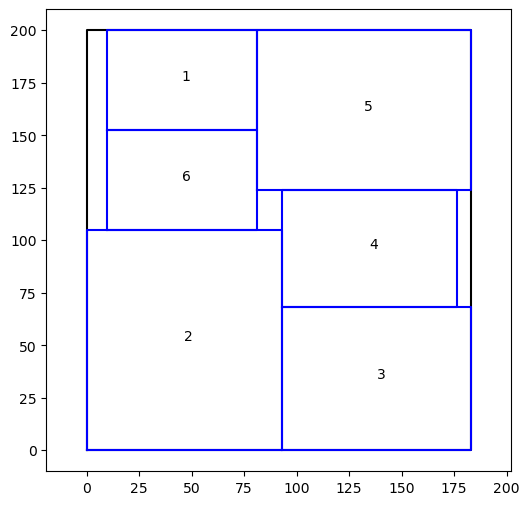

In [1]:
import cvxpy as cp
import numpy as np
import math
import matplotlib.pyplot as plt

n = 6

areas = [3600, 10000, 6400, 4900, 8100, 3600]

flows = [
    [0, 0, 20, 40, 60, 0],
    [0, 0, 50, 15, 0, 60],
    [20, 50, 0, 50, 10, 10],
    [40, 15, 50, 0, 10, 0],
    [60, 0, 10, 10, 0, 0],
    [0, 60, 10, 0, 0, 0]
]

Bx = 183
By = 200

L = cp.Variable(n)
W = cp.Variable(n)
X = cp.Variable(n)
Y = cp.Variable(n)

M = 10000
constraints = []

for i in range(n):
    constraints.append(L[i] >= 25)
    constraints.append(L[i] <= 200)
    constraints.append(W[i] >= 40)
    constraints.append(W[i] <= 200)

    constraints.append(X[i] - 0.5 * L[i] >= 0)
    constraints.append(X[i] + 0.5 * L[i] <= Bx)
    constraints.append(Y[i] - 0.5 * W[i] >= 0)
    constraints.append(Y[i] + 0.5 * W[i] <= By)

    s = math.sqrt(areas[i])
    p = 4 * s
    constraints.append(2 * (L[i] + W[i]) >= 0.99 * p)
    constraints.append(2 * (L[i] + W[i]) <= 1.01 * p)
    
    constraints.append(L[i] <= 1.5 * W[i])
    constraints.append(W[i] <= 1.5 * L[i])

dx = {}
dy = {}
zL = {}
zR = {}
zB = {}
zA = {}
obj_terms = []

for i in range(n):
    for j in range(i + 1, n):
        zL[i, j] = cp.Variable(boolean=True)
        zR[i, j] = cp.Variable(boolean=True)
        zB[i, j] = cp.Variable(boolean=True)
        zA[i, j] = cp.Variable(boolean=True)

        dx[i, j] = cp.Variable(nonneg=True)
        dy[i, j] = cp.Variable(nonneg=True)

        constraints.append(dx[i, j] >= X[i] - X[j])
        constraints.append(dx[i, j] >= X[j] - X[i])
        constraints.append(dy[i, j] >= Y[i] - Y[j])
        constraints.append(dy[i, j] >= Y[j] - Y[i])

        constraints.append(X[i] + 0.5*L[i] <= X[j] - 0.5*L[j] + M*(1 - zL[i, j]))
        constraints.append(X[j] + 0.5*L[j] <= X[i] - 0.5*L[i] + M*(1 - zR[i, j]))
        constraints.append(Y[i] + 0.5*W[i] <= Y[j] - 0.5*W[j] + M*(1 - zB[i, j]))
        constraints.append(Y[j] + 0.5*W[j] <= Y[i] - 0.5*W[i] + M*(1 - zA[i, j]))
        
        constraints.append(zL[i, j] + zR[i, j] + zB[i, j] + zA[i, j] >= 1)

        cost = flows[i][j] + flows[j][i]
        obj_terms.append(cost * (dx[i, j] + dy[i, j]))

constraints.append(X[0] + 0.5*L[0] <= X[4] - 0.5*L[4])
constraints.append(zL[0, 4] == 1)

prob = cp.Problem(cp.Minimize(cp.sum(obj_terms)), constraints)
prob.solve(solver=cp.MOSEK)

print("Optimal:", prob.value)

for i in range(n):
    print(i+1, round(L[i].value, 2), round(W[i].value, 2), round(X[i].value, 2), round(Y[i].value, 2))

plt.figure(figsize=(6, 6))
plt.plot([0, Bx, Bx, 0, 0], [0, 0, By, By, 0], 'k-')

for i in range(n):
    xi = X[i].value
    yi = Y[i].value
    li = L[i].value
    wi = W[i].value
    
    plt.plot([xi - li/2, xi + li/2, xi + li/2, xi - li/2, xi - li/2],
             [yi - wi/2, yi - wi/2, yi + wi/2, yi + wi/2, yi - wi/2], 'b-')
    plt.text(xi, yi, str(i+1))

plt.axis('equal')
plt.show()